In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
X_train = pd.read_csv("data/x_train.txt", sep = " ")
y_train = pd.read_csv("data/y_train.txt", sep = " ")
n_old, p_old = X_train.shape

X_train = X_train.T.drop_duplicates().T
X_train.drop_duplicates(inplace=True)
n, p = X_train.shape

In [9]:
print(f"Shape: n = {n}, p = {p}")
print(f"Class 1: {np.mean(y_train) * 100:0.2f}%")
print(f"Column types: {np.unique(X_train.dtypes)}")
print(f"Missing data: {np.sum(np.sum(X_train.isna(), axis=1), axis=0)}")
print(f"Column duplicates: {p_old - p}, row duplicates: {n_old - n}")

Shape: n = 5000, p = 498
Class 1: 49.76%
Column types: [dtype('float64')]
Missing data: 0
Column duplicates: 2, row duplicates: 0


In [10]:
X_train.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V491,V492,V493,V494,V495,V496,V497,V498,V499,V500
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.500233,0.500273,10.048039,0.495947,0.025057,0.496769,0.498385,0.498027,0.493844,-0.022705,...,-0.005252,0.503225,0.500664,0.005485,9.983796,0.014929,0.495957,9.953891,-0.017337,0.497873
std,0.286156,0.285742,4.582863,0.286356,2.480097,0.292497,0.290257,0.291401,0.289450,0.993465,...,1.000026,0.286948,0.291534,1.004822,4.487236,0.991845,0.290911,4.435534,0.990030,0.288636
min,0.000195,0.000107,0.958113,0.000026,-8.803497,0.000116,0.000075,0.000060,0.000095,-3.693892,...,-3.750717,0.000151,0.000105,-3.587849,0.986320,-3.358077,0.000163,0.940390,-3.381385,0.000106
25%,0.254151,0.247001,6.771772,0.248746,-1.613801,0.241448,0.247769,0.240210,0.242509,-0.712855,...,-0.665776,0.256773,0.245910,-0.676383,6.716957,-0.658023,0.243473,6.685453,-0.675339,0.250572
50%,0.506632,0.502785,9.310201,0.500593,0.022467,0.494284,0.498828,0.498829,0.488783,-0.019341,...,0.001532,0.504650,0.499564,0.009176,9.370211,0.016059,0.500924,9.286676,-0.012790,0.497029
75%,0.743107,0.746211,12.658089,0.741587,1.693679,0.756912,0.748557,0.744075,0.748062,0.651148,...,0.646321,0.748965,0.756052,0.683569,12.524212,0.696753,0.747700,12.458401,0.662880,0.746191
max,0.999599,0.999994,33.537836,0.999796,9.441396,0.999849,0.999791,0.999605,0.999690,3.145788,...,3.861070,0.999976,0.999963,3.789411,39.996344,4.547909,0.999711,30.002210,3.460326,0.999529


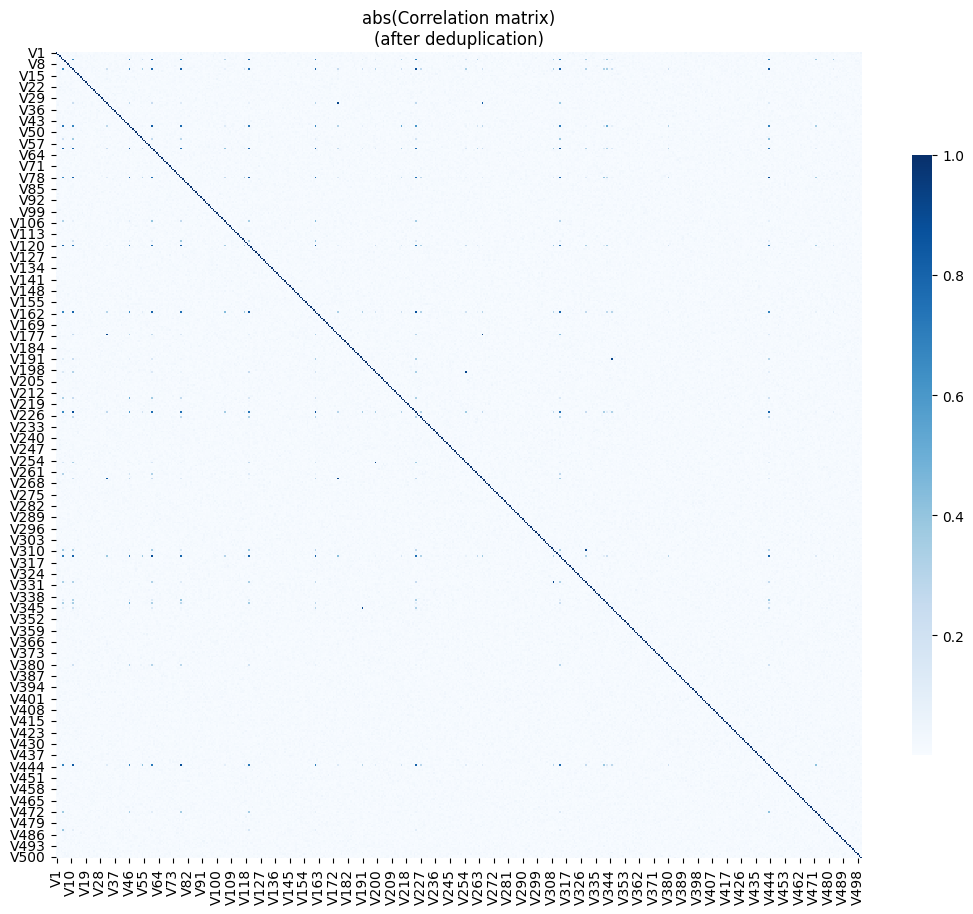

In [ ]:
corr_matrix = np.abs(X_train.corr())
fig, ax = plt.subplots(figsize=(13, 13))
sns.heatmap(
    corr_matrix,
    square=True,
    cmap="Blues",
    cbar_kws={"shrink": 0.6, "aspect": 30})
plt.title("abs(Correlation matrix)\nafter deduplication")
plt.show()

In [24]:
# columns with correlation > 0.85
corr_matrix = np.abs(X_train.corr())

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.85
]
for elem in high_corr_pairs:
    print(elem)

('V176', 'V32', np.float64(0.9152183464604331))
('V224', 'V11', np.float64(0.8807696253441699))
('V224', 'V161', np.float64(0.8710001292081314))
('V255', 'V199', np.float64(0.9103210476984752))
('V265', 'V176', np.float64(0.9121312557222008))
('V313', 'V60', np.float64(0.8851603803348861))
('V329', 'V309', np.float64(0.9120051194651927))
('V345', 'V191', np.float64(0.912227974718394))
('V443', 'V78', np.float64(0.8825319202119688))


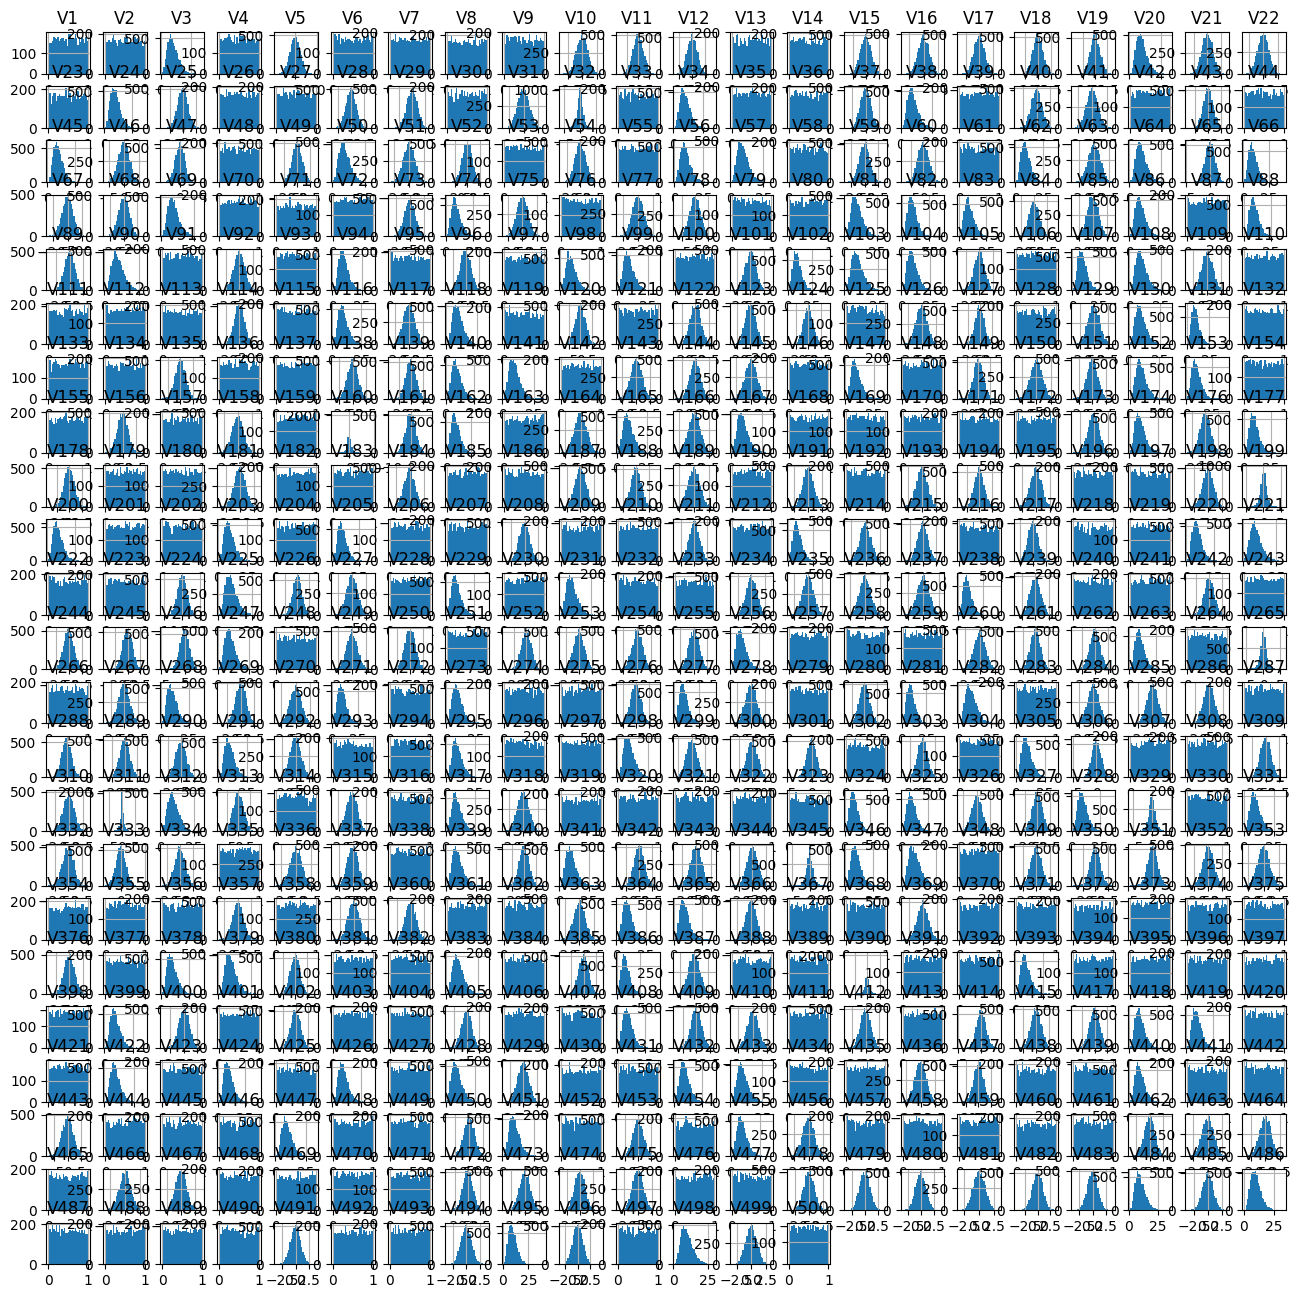

In [ ]:
X_train.hist(figsize=(16, 16), bins=30)
plt.show()
# all predictors are look like either normal, gamma (skewed to the right) or uniform distribution ?
# hard to notice any "anomalities"